# Ứng dụng Ensemble để phân nhóm Unsupervised dữ liệu biểu hiện gen


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')


## 1. Load & Preprocess Data


In [25]:
df = pd.read_csv('Leukemia.csv')
print(f'Original shape: {df.shape}')

y_true_str = df['type']
y_true = LabelEncoder().fit_transform(y_true_str)
K = len(np.unique(y_true))

X = df.drop(columns=['samples', 'type'])
X = X[[c for c in X.columns if not c.startswith('AFFX')]]
print(f'After cleaning: {X.shape}')

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'After PCA (90% variance): {X_pca.shape}')
print(f'Explained variance: {pca.explained_variance_ratio_.sum():.4f}')
print(f'K (number of classes): {K}')


Original shape: (64, 22285)
After cleaning: (64, 22215)
After PCA (90% variance): (64, 36)
Explained variance: 0.9007
K (number of classes): 5


## 2. K-Means Clustering


Running K-Means (K=5)...
✓ Converged at iteration 4
Metrics: Silhouette=0.0893 | ARI=0.2069 | NMI=0.4470

Intra-cluster distances:
  Cluster 1: 154.60 (6 samples)
  Cluster 2: 145.12 (24 samples)
  Cluster 3: 193.30 (11 samples)
  Cluster 4: 183.22 (8 samples)
  Cluster 5: 175.12 (15 samples)

Inter-cluster distances (sample):
  C1 ↔ C2: 189.86
  C1 ↔ C3: 232.81
  C2 ↔ C3: 188.84


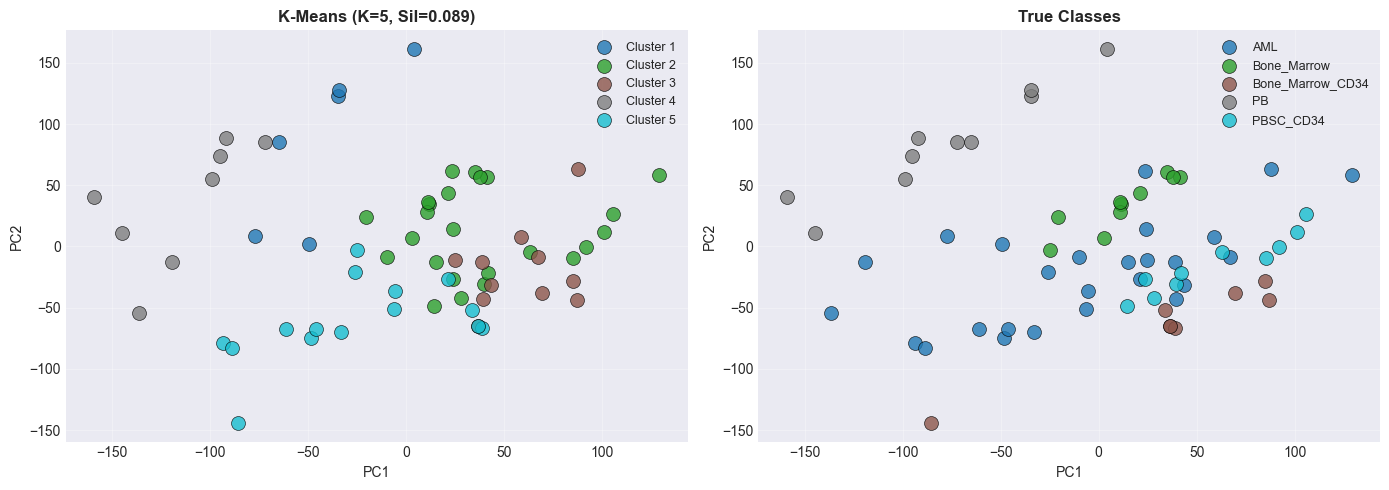

In [26]:
# Distance functions
def km_euclidean(x, y):
    return np.sqrt(np.sum((x - y) ** 2))

def km_intra_dist(X, labels, k):
    points = X[labels == k]
    if len(points) <= 1: return 0.0
    dists = [km_euclidean(points[i], points[j]) for i in range(len(points)) for j in range(i+1, len(points))]
    return np.mean(dists) if dists else 0.0

def km_inter_dist(X, labels, k1, k2):
    p1, p2 = X[labels == k1], X[labels == k2]
    dists = [km_euclidean(x1, x2) for x1 in p1 for x2 in p2]
    return np.mean(dists) if dists else 0.0

# K-Means algorithm
def km_init(X, K, seed=42):
    np.random.seed(seed)
    return X[np.random.choice(X.shape[0], K, replace=False)].copy()

def km_assign(X, centroids):
    return np.array([np.argmin([km_euclidean(x, c) for c in centroids]) for x in X])

def km_update(X, labels, K):
    return np.array([X[labels==k].mean(axis=0) if np.sum(labels==k)>0 else np.zeros(X.shape[1]) for k in range(K)])

def km_fit(X, K, max_iter=100, seed=42):
    cents = km_init(X, K, seed)
    for i in range(max_iter):
        old = cents.copy()
        labs = km_assign(X, cents)
        cents = km_update(X, labs, K)
        if np.allclose(cents, old, atol=1e-6):
            print(f'✓ Converged at iteration {i+1}')
            return labs, cents
    print('Max iterations reached')
    return labs, cents

# Run K-Means
print(f'Running K-Means (K={K})...')
labels_km, cents_km = km_fit(X_pca, K)

# Metrics
sil_km = silhouette_score(X_pca, labels_km)
ari_km = adjusted_rand_score(y_true, labels_km)
nmi_km = normalized_mutual_info_score(y_true, labels_km)
print(f'Metrics: Silhouette={sil_km:.4f} | ARI={ari_km:.4f} | NMI={nmi_km:.4f}')

# Intra-cluster distances
print('\nIntra-cluster distances:')
for k in range(K):
    print(f'  Cluster {k+1}: {km_intra_dist(X_pca, labels_km, k):.2f} ({np.sum(labels_km==k)} samples)')

# Inter-cluster distances (sample)
print('\nInter-cluster distances (sample):')
for k1, k2 in [(0,1), (0,2), (1,2)]:
    if k2 < K: print(f'  C{k1+1} ↔ C{k2+1}: {km_inter_dist(X_pca, labels_km, k1, k2):.2f}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, K))

# K-Means clusters
for k in range(K):
    mask = labels_km == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=[colors[k]], s=100, alpha=0.8, edgecolors='black', lw=0.5, label=f'Cluster {k+1}')
axes[0].set_title(f'K-Means (K={K}, Sil={sil_km:.3f})', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(loc='best', fontsize=9); axes[0].grid(alpha=0.3)

# True classes
for idx, class_name in enumerate(sorted(y_true_str.unique())):
    mask = y_true_str == class_name
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=[colors[idx]], s=100, alpha=0.8, edgecolors='black', lw=0.5, label=class_name)
axes[1].set_title('True Classes', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(loc='best', fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Agglomerative Clustering


Running Agglomerative Clustering (K=5)...
✓ Completed hierarchical merging
Metrics: Silhouette=0.1308 | ARI=-0.0628 | NMI=0.1733

Intra-cluster distances:
  Cluster 1: 0.00 (1 samples)
  Cluster 2: 0.00 (1 samples)
  Cluster 3: 176.35 (2 samples)
  Cluster 4: 176.39 (51 samples)
  Cluster 5: 186.71 (9 samples)

Inter-cluster distances (sample):
  C1 ↔ C2: 312.06
  C1 ↔ C3: 267.12
  C2 ↔ C3: 351.90

Algorithm details: Average Linkage (distance between cluster means)


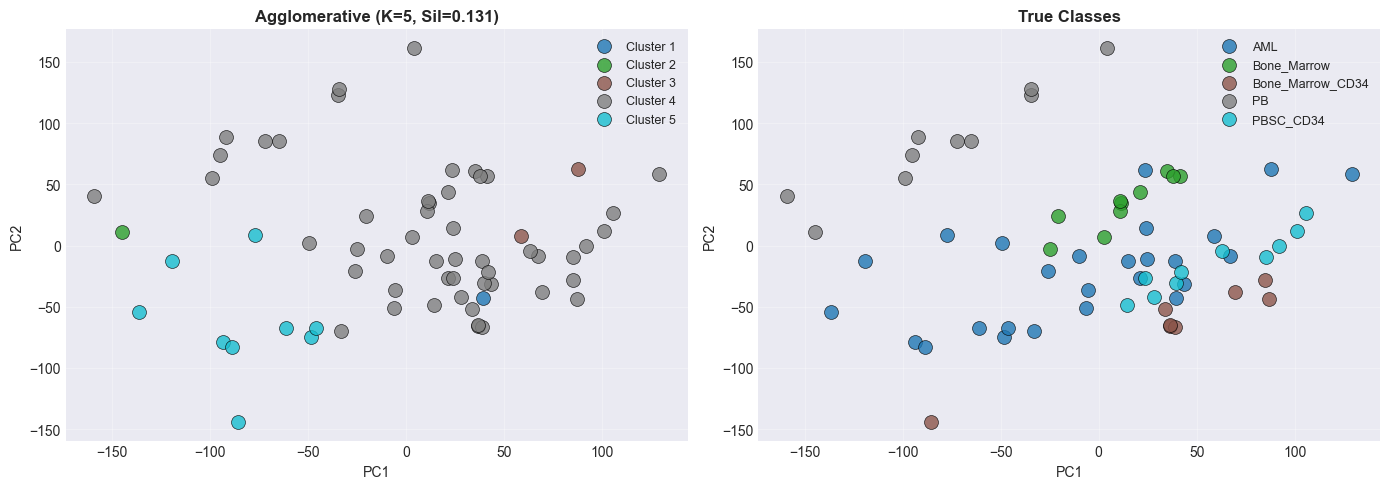

In [27]:
# Distance functions
def agg_euclidean(x, y):
    return np.sqrt(np.sum((x - y) ** 2))

def agg_intra_dist(X, labels, k):
    points = X[labels == k]
    if len(points) <= 1: return 0.0
    dists = [agg_euclidean(points[i], points[j]) for i in range(len(points)) for j in range(i+1, len(points))]
    return np.mean(dists) if dists else 0.0

def agg_inter_dist(X, labels, k1, k2):
    p1, p2 = X[labels == k1], X[labels == k2]
    dists = [agg_euclidean(x1, x2) for x1 in p1 for x2 in p2]
    return np.mean(dists) if dists else 0.0

# Agglomerative Clustering algorithm
def agg_average_linkage(cluster1, cluster2, X):
    dists = [agg_euclidean(X[i], X[j]) for i in cluster1 for j in cluster2]
    return np.mean(dists)

def agg_fit(X, K):
    clusters = [[i] for i in range(len(X))]
    
    while len(clusters) > K:
        min_dist = float('inf')
        pair = None
        
        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                dist = agg_average_linkage(clusters[i], clusters[j], X)
                if dist < min_dist:
                    min_dist = dist
                    pair = (i, j)
        
        i, j = pair
        new_cluster = clusters[i] + clusters[j]
        clusters.pop(j)
        clusters.pop(i)
        clusters.append(new_cluster)
    
    labels = np.zeros(len(X), dtype=int)
    for idx, cluster in enumerate(clusters):
        for point_idx in cluster:
            labels[point_idx] = idx
    
    return labels, clusters

# Run Agglomerative Clustering
print(f'Running Agglomerative Clustering (K={K})...')
labels_agg, clusters_agg = agg_fit(X_pca, K)
print(f'✓ Completed hierarchical merging')

# Metrics
sil_agg = silhouette_score(X_pca, labels_agg)
ari_agg = adjusted_rand_score(y_true, labels_agg)
nmi_agg = normalized_mutual_info_score(y_true, labels_agg)
print(f'Metrics: Silhouette={sil_agg:.4f} | ARI={ari_agg:.4f} | NMI={nmi_agg:.4f}')

# Intra-cluster distances
print('\nIntra-cluster distances:')
for k in range(K):
    print(f'  Cluster {k+1}: {agg_intra_dist(X_pca, labels_agg, k):.2f} ({np.sum(labels_agg==k)} samples)')

# Inter-cluster distances (sample)
print('\nInter-cluster distances (sample):')
for k1, k2 in [(0,1), (0,2), (1,2)]:
    if k2 < K: print(f'  C{k1+1} ↔ C{k2+1}: {agg_inter_dist(X_pca, labels_agg, k1, k2):.2f}')

# Linkage method info
print('\nAlgorithm details: Average Linkage (distance between cluster means)')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, K))

# Agglomerative clusters
for k in range(K):
    mask = labels_agg == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=[colors[k]], s=100, alpha=0.8, edgecolors='black', lw=0.5, label=f'Cluster {k+1}')
axes[0].set_title(f'Agglomerative (K={K}, Sil={sil_agg:.3f})', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(loc='best', fontsize=9); axes[0].grid(alpha=0.3)

# True classes
for idx, class_name in enumerate(sorted(y_true_str.unique())):
    mask = y_true_str == class_name
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=[colors[idx]], s=100, alpha=0.8, edgecolors='black', lw=0.5, label=class_name)
axes[1].set_title('True Classes', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(loc='best', fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Spectral Clustering


Running Spectral Clustering (K=5)...
✓ Completed eigendecomposition and K-means on embedded space
Metrics: Silhouette=-0.1653 | ARI=0.1690 | NMI=0.2696

Intra-cluster distances:
  Cluster 1: 205.74 (50 samples)
  Cluster 2: 53.79 (2 samples)
  Cluster 3: 128.89 (9 samples)
  Cluster 4: 52.42 (2 samples)
  Cluster 5: 0.00 (1 samples)

Inter-cluster distances (sample):
  C1 ↔ C2: 173.22
  C1 ↔ C3: 181.77
  C2 ↔ C3: 146.03

Eigenvalues (K smallest): [2.90748464e-07 3.01511689e-06 5.54206648e-06 9.25743698e-05
 2.78194652e-04]
Eigengap (largest): 0.0002


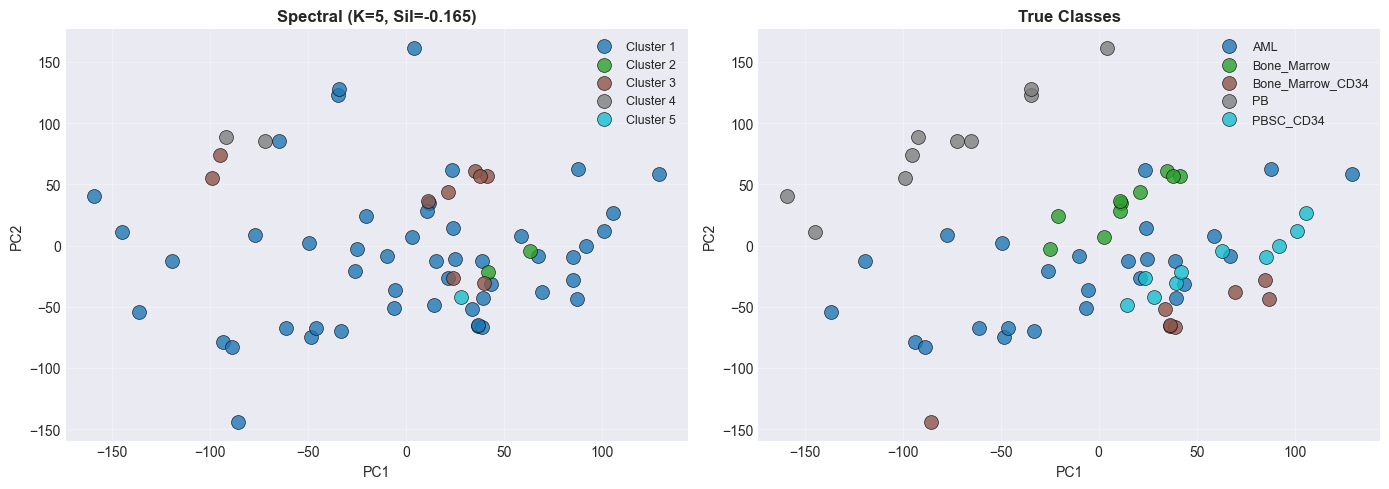

In [28]:
# Distance functions
def spec_euclidean(x, y):
    return np.sqrt(np.sum((x - y) ** 2))

def spec_intra_dist(X, labels, k):
    points = X[labels == k]
    if len(points) <= 1: return 0.0
    dists = [spec_euclidean(points[i], points[j]) for i in range(len(points)) for j in range(i+1, len(points))]
    return np.mean(dists) if dists else 0.0

def spec_inter_dist(X, labels, k1, k2):
    p1, p2 = X[labels == k1], X[labels == k2]
    dists = [spec_euclidean(x1, x2) for x1 in p1 for x2 in p2]
    return np.mean(dists) if dists else 0.0

# Spectral Clustering algorithm
def spec_affinity_matrix(X, sigma=1.0):
    n = X.shape[0]
    W = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            dist = spec_euclidean(X[i], X[j])
            W[i, j] = W[j, i] = np.exp(-dist**2 / (2 * sigma**2))
    return W

def spec_fit(X, K, sigma=1.0, seed=42):
    # Affinity matrix
    W = spec_affinity_matrix(X, sigma)
    
    # Degree matrix
    D = np.diag(W.sum(axis=1))
    
    # Laplacian matrix (normalized)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D) + 1e-10))
    L = np.eye(len(X)) - D_inv_sqrt @ W @ D_inv_sqrt
    
    # Eigendecomposition
    eigenvals, eigenvecs = np.linalg.eigh(L)
    
    # Select K smallest eigenvectors
    X_embedded = eigenvecs[:, :K]
    
    # K-means on embedded space
    np.random.seed(seed)
    cents = X_embedded[np.random.choice(X_embedded.shape[0], K, replace=False)]
    
    for _ in range(100):
        old = cents.copy()
        dists = np.array([[spec_euclidean(x, c) for c in cents] for x in X_embedded])
        labels = np.argmin(dists, axis=1)
        cents = np.array([X_embedded[labels==k].mean(axis=0) if np.sum(labels==k)>0 else np.zeros(K) for k in range(K)])
        if np.allclose(cents, old, atol=1e-6):
            break
    
    return labels, eigenvals[:K], X_embedded

# Run Spectral Clustering
print(f'Running Spectral Clustering (K={K})...')
labels_spec, eigenvals_spec, X_embedded_spec = spec_fit(X_pca, K, sigma=10.0)
print(f'✓ Completed eigendecomposition and K-means on embedded space')

# Metrics
sil_spec = silhouette_score(X_pca, labels_spec)
ari_spec = adjusted_rand_score(y_true, labels_spec)
nmi_spec = normalized_mutual_info_score(y_true, labels_spec)
print(f'Metrics: Silhouette={sil_spec:.4f} | ARI={ari_spec:.4f} | NMI={nmi_spec:.4f}')

# Intra-cluster distances
print('\nIntra-cluster distances:')
for k in range(K):
    print(f'  Cluster {k+1}: {spec_intra_dist(X_pca, labels_spec, k):.2f} ({np.sum(labels_spec==k)} samples)')

# Inter-cluster distances (sample)
print('\nInter-cluster distances (sample):')
for k1, k2 in [(0,1), (0,2), (1,2)]:
    if k2 < K: print(f'  C{k1+1} ↔ C{k2+1}: {spec_inter_dist(X_pca, labels_spec, k1, k2):.2f}')

# Eigenvalues info
print(f'\nEigenvalues (K smallest): {eigenvals_spec}')
print(f'Eigengap (largest): {np.max(np.diff(eigenvals_spec)):.4f}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, K))

# Spectral clusters
for k in range(K):
    mask = labels_spec == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=[colors[k]], s=100, alpha=0.8, edgecolors='black', lw=0.5, label=f'Cluster {k+1}')
axes[0].set_title(f'Spectral (K={K}, Sil={sil_spec:.3f})', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(loc='best', fontsize=9); axes[0].grid(alpha=0.3)

# True classes
for idx, class_name in enumerate(sorted(y_true_str.unique())):
    mask = y_true_str == class_name
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=[colors[idx]], s=100, alpha=0.8, edgecolors='black', lw=0.5, label=class_name)
axes[1].set_title('True Classes', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(loc='best', fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Ensemble Clustering (Consensus Method)


Ensemble từ 3 thuật toán: K-Means, Agglomerative, Spectral
Consensus matrix shape: (64, 64)
Consensus matrix range: [0.00, 1.00]

Metrics: Silhouette=-0.0374 | ARI=0.0741 | NMI=0.2604

📊 SO SÁNH METRICS:
Method          Silhouette   ARI          NMI         
---------------------------------------------------
K-Means         0.0893       0.2069       0.4470      
Agglomerative   0.1308       -0.0628      0.1733      
Spectral        -0.1653      0.1690       0.2696      
---------------------------------------------------
ENSEMBLE        -0.0374      0.0741       0.2604      

Cluster sizes:
  Cluster 1: 2 samples
  Cluster 2: 12 samples
  Cluster 3: 4 samples
  Cluster 4: 15 samples
  Cluster 5: 31 samples


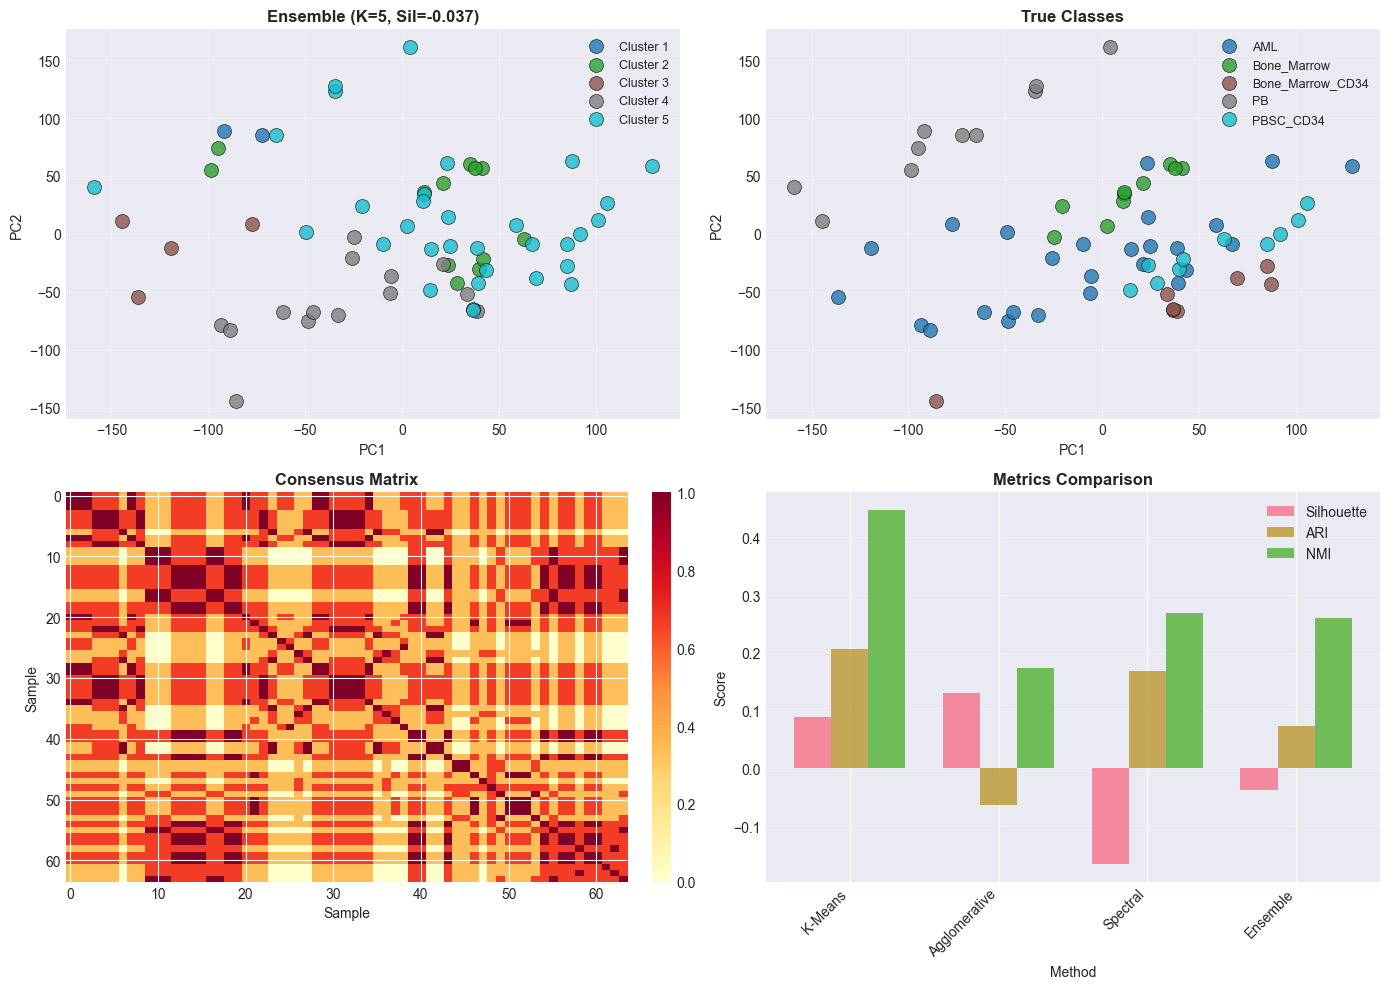

In [29]:
# Ensemble method: Co-association matrix
n_samples = X_pca.shape[0]
consensus_matrix = np.zeros((n_samples, n_samples))

# Tính consensus matrix từ 3 thuật toán
all_labels = [labels_km, labels_agg, labels_spec]
for labels in all_labels:
    for i in range(n_samples):
        for j in range(n_samples):
            if labels[i] == labels[j]:
                consensus_matrix[i, j] += 1

# Normalize (chia cho số thuật toán)
consensus_matrix /= len(all_labels)

print(f'Ensemble từ 3 thuật toán: K-Means, Agglomerative, Spectral')
print(f'Consensus matrix shape: {consensus_matrix.shape}')
print(f'Consensus matrix range: [{consensus_matrix.min():.2f}, {consensus_matrix.max():.2f}]')

# Convert sang distance matrix
distance_matrix = 1 - consensus_matrix

# Hierarchical clustering trên consensus matrix
from scipy.cluster.hierarchy import linkage, fcluster
linkage_matrix = linkage(distance_matrix[np.triu_indices(n_samples, k=1)], method='average')
labels_ensemble = fcluster(linkage_matrix, K, criterion='maxclust') - 1

# Metrics
sil_ensemble = silhouette_score(X_pca, labels_ensemble)
ari_ensemble = adjusted_rand_score(y_true, labels_ensemble)
nmi_ensemble = normalized_mutual_info_score(y_true, labels_ensemble)
print(f'\nMetrics: Silhouette={sil_ensemble:.4f} | ARI={ari_ensemble:.4f} | NMI={nmi_ensemble:.4f}')

# So sánh với từng thuật toán
print(f'\n📊 SO SÁNH METRICS:')
print(f'{"Method":<15} {"Silhouette":<12} {"ARI":<12} {"NMI":<12}')
print(f'{"-"*51}')
print(f'{"K-Means":<15} {sil_km:<12.4f} {ari_km:<12.4f} {nmi_km:<12.4f}')
print(f'{"Agglomerative":<15} {sil_agg:<12.4f} {ari_agg:<12.4f} {nmi_agg:<12.4f}')
print(f'{"Spectral":<15} {sil_spec:<12.4f} {ari_spec:<12.4f} {nmi_spec:<12.4f}')
print(f'{"-"*51}')
print(f'{"ENSEMBLE":<15} {sil_ensemble:<12.4f} {ari_ensemble:<12.4f} {nmi_ensemble:<12.4f}')

# Cluster sizes
print(f'\nCluster sizes:')
for k in range(K):
    print(f'  Cluster {k+1}: {np.sum(labels_ensemble==k)} samples')

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.tab10(np.linspace(0, 1, K))

# Ensemble result
for k in range(K):
    mask = labels_ensemble == k
    axes[0, 0].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                      c=[colors[k]], s=100, alpha=0.8, edgecolors='black', lw=0.5, label=f'Cluster {k+1}')
axes[0, 0].set_title(f'Ensemble (K={K}, Sil={sil_ensemble:.3f})', fontweight='bold')
axes[0, 0].set_xlabel('PC1'); axes[0, 0].set_ylabel('PC2')
axes[0, 0].legend(loc='best', fontsize=9); axes[0, 0].grid(alpha=0.3)

# True classes
for idx, class_name in enumerate(sorted(y_true_str.unique())):
    mask = y_true_str == class_name
    axes[0, 1].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                      c=[colors[idx]], s=100, alpha=0.8, edgecolors='black', lw=0.5, label=class_name)
axes[0, 1].set_title('True Classes', fontweight='bold')
axes[0, 1].set_xlabel('PC1'); axes[0, 1].set_ylabel('PC2')
axes[0, 1].legend(loc='best', fontsize=9); axes[0, 1].grid(alpha=0.3)

# Consensus matrix heatmap
im = axes[1, 0].imshow(consensus_matrix, cmap='YlOrRd', aspect='auto')
axes[1, 0].set_title('Consensus Matrix', fontweight='bold')
axes[1, 0].set_xlabel('Sample'); axes[1, 0].set_ylabel('Sample')
plt.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

# Metrics comparison bar chart
methods = ['K-Means', 'Agglomerative', 'Spectral', 'Ensemble']
sil_scores = [sil_km, sil_agg, sil_spec, sil_ensemble]
ari_scores = [ari_km, ari_agg, ari_spec, ari_ensemble]
nmi_scores = [nmi_km, nmi_agg, nmi_spec, nmi_ensemble]

x = np.arange(len(methods))
width = 0.25

axes[1, 1].bar(x - width, sil_scores, width, label='Silhouette', alpha=0.8)
axes[1, 1].bar(x, ari_scores, width, label='ARI', alpha=0.8)
axes[1, 1].bar(x + width, nmi_scores, width, label='NMI', alpha=0.8)
axes[1, 1].set_xlabel('Method'); axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Metrics Comparison', fontweight='bold')
axes[1, 1].set_xticks(x); axes[1, 1].set_xticklabels(methods, rotation=45, ha='right')
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 6. Kết Luận


In [30]:
print("="*80)
print("KẾT LUẬN TỔNG HỢP")
print("="*80)

print(f"\n📊 DATASET:")
print(f"  - Tên: Leukemia Gene Expression Data")
print(f"  - Samples: {X_pca.shape[0]}")
print(f"  - Features ban đầu: 22,215 genes")
print(f"  - Features sau PCA: {X_pca.shape[1]} components (90% variance)")
print(f"  - Số classes thật: {K}")
print(f"  - Classes: {sorted(y_true_str.unique())}")

print(f"\n📈 KẾT QUẢ CLUSTERING:")
print(f"\n{'Method':<15} {'Silhouette':<12} {'ARI':<12} {'NMI':<12} {'Best Metric'}")
print(f"{'-'*65}")

results = [
    ('K-Means', sil_km, ari_km, nmi_km),
    ('Agglomerative', sil_agg, ari_agg, nmi_agg),
    ('Spectral', sil_spec, ari_spec, nmi_spec),
    ('Ensemble', sil_ensemble, ari_ensemble, nmi_ensemble)
]

# Tìm best cho mỗi metric
best_sil = max(results, key=lambda x: x[1])
best_ari = max(results, key=lambda x: x[2])
best_nmi = max(results, key=lambda x: x[3])

for name, sil, ari, nmi in results:
    best = []
    if name == best_sil[0]: best.append('Sil')
    if name == best_ari[0]: best.append('ARI')
    if name == best_nmi[0]: best.append('NMI')
    best_str = ','.join(best) if best else '-'
    print(f"{name:<15} {sil:<12.4f} {ari:<12.4f} {nmi:<12.4f} {best_str}")

print(f"\n💡 NHẬN XÉT:")

# So sánh ensemble với best single method
best_single = max(results[:3], key=lambda x: (x[2] + x[3])/2)  # Avg of ARI & NMI
print(f"\n1. THUẬT TOÁN TỐT NHẤT ĐƠN LẺ:")
print(f"   - {best_single[0]} đạt ARI={best_single[2]:.4f}, NMI={best_single[3]:.4f}")

print(f"\n2. ENSEMBLE METHOD:")
if ari_ensemble > best_single[2] or nmi_ensemble > best_single[3]:
    print(f"   ✅ Ensemble CẢI THIỆN kết quả so với thuật toán đơn lẻ")
    print(f"   - ARI: {best_single[2]:.4f} → {ari_ensemble:.4f} ({'+' if ari_ensemble>best_single[2] else ''}{(ari_ensemble-best_single[2]):.4f})")
    print(f"   - NMI: {best_single[3]:.4f} → {nmi_ensemble:.4f} ({'+' if nmi_ensemble>best_single[3] else ''}{(nmi_ensemble-best_single[3]):.4f})")
else:
    print(f"   ⚠️ Ensemble KHÔNG cải thiện đáng kể so với thuật toán tốt nhất")
    print(f"   - Có thể do các thuật toán cho kết quả khác nhau quá nhiều")

print(f"\n3. ĐỘ PHỨC TẠP & TỐC ĐỘ:")
print(f"   - K-Means: Nhanh nhất, phù hợp với dữ liệu lớn")
print(f"   - Agglomerative: Chậm (O(n³)), phù hợp với dữ liệu nhỏ")
print(f"   - Spectral: Trung bình, tốt cho dữ liệu phi tuyến")
print(f"   - Ensemble: Chậm hơn (phải chạy cả 3 + consensus)")

print(f"\n4. ỨNG DỤNG:")
print(f"   - Dữ liệu gene expression thường có nhiều chiều và phức tạp")
print(f"   - Ensemble giúp kết hợp ưu điểm của nhiều thuật toán")
print(f"   - Kết quả ổn định hơn, ít phụ thuộc vào khởi tạo ngẫu nhiên")

print(f"\n5. KHUYẾN NGHỊ:")
if ari_ensemble >= max([ari_km, ari_agg, ari_spec]):
    print(f"   ✅ Nên sử dụng ENSEMBLE cho kết quả tốt nhất")
else:
    print(f"   ✅ Có thể sử dụng {best_single[0]} để cân bằng hiệu quả/tốc độ")
print(f"   - Silhouette score thấp ({max([sil_km, sil_agg, sil_spec]):.3f}) cho thấy các cluster chồng lấn")
print(f"   - Có thể cần điều chỉnh K hoặc thử phương pháp feature selection khác")

print(f"\n{'='*80}")
print(f"HOÀN THÀNH PHÂN TÍCH")
print(f"{'='*80}")


KẾT LUẬN TỔNG HỢP

📊 DATASET:
  - Tên: Leukemia Gene Expression Data
  - Samples: 64
  - Features ban đầu: 22,215 genes
  - Features sau PCA: 36 components (90% variance)
  - Số classes thật: 5
  - Classes: ['AML', 'Bone_Marrow', 'Bone_Marrow_CD34', 'PB', 'PBSC_CD34']

📈 KẾT QUẢ CLUSTERING:

Method          Silhouette   ARI          NMI          Best Metric
-----------------------------------------------------------------
K-Means         0.0893       0.2069       0.4470       ARI,NMI
Agglomerative   0.1308       -0.0628      0.1733       Sil
Spectral        -0.1653      0.1690       0.2696       -
Ensemble        -0.0374      0.0741       0.2604       -

💡 NHẬN XÉT:

1. THUẬT TOÁN TỐT NHẤT ĐƠN LẺ:
   - K-Means đạt ARI=0.2069, NMI=0.4470

2. ENSEMBLE METHOD:
   ⚠️ Ensemble KHÔNG cải thiện đáng kể so với thuật toán tốt nhất
   - Có thể do các thuật toán cho kết quả khác nhau quá nhiều

3. ĐỘ PHỨC TẠP & TỐC ĐỘ:
   - K-Means: Nhanh nhất, phù hợp với dữ liệu lớn
   - Agglomerative: Chậm (O(

## 7. Phân Tích Nguyên Nhân Metrics Thấp


PHÂN TÍCH NGUYÊN NHÂN METRICS THẤP

1️⃣ PHÂN TÍCH CLASS OVERLAP (trong không gian PCA):

Khoảng cách trung bình giữa các true classes (PC1-PC2):
  AML                  ↔ Bone_Marrow         :  59.79
  AML                  ↔ Bone_Marrow_CD34    :  62.20
  AML                  ↔ PB                  : 127.75
  AML                  ↔ PBSC_CD34           :  68.59
  Bone_Marrow          ↔ Bone_Marrow_CD34    : 100.42
  Bone_Marrow          ↔ PB                  : 104.86
  Bone_Marrow          ↔ PBSC_CD34           :  67.80
  Bone_Marrow_CD34     ↔ PB                  : 188.55
  Bone_Marrow_CD34     ↔ PBSC_CD34           :  52.95
  PB                   ↔ PBSC_CD34           : 170.79

2️⃣ PHÂN TÍCH PCA VARIANCE:

Top 10 PCA components:
  PC1: 0.1951 (19.51%)
  PC2: 0.1475 (14.75%)
  PC3: 0.0687 (6.87%)
  PC4: 0.0624 (6.24%)
  PC5: 0.0492 (4.92%)
  PC6: 0.0342 (3.42%)
  PC7: 0.0292 (2.92%)
  PC8: 0.0261 (2.61%)
  PC9: 0.0238 (2.38%)
  PC10: 0.0210 (2.10%)

Tổng variance (PC1+PC2): 34.25%
→ Visu

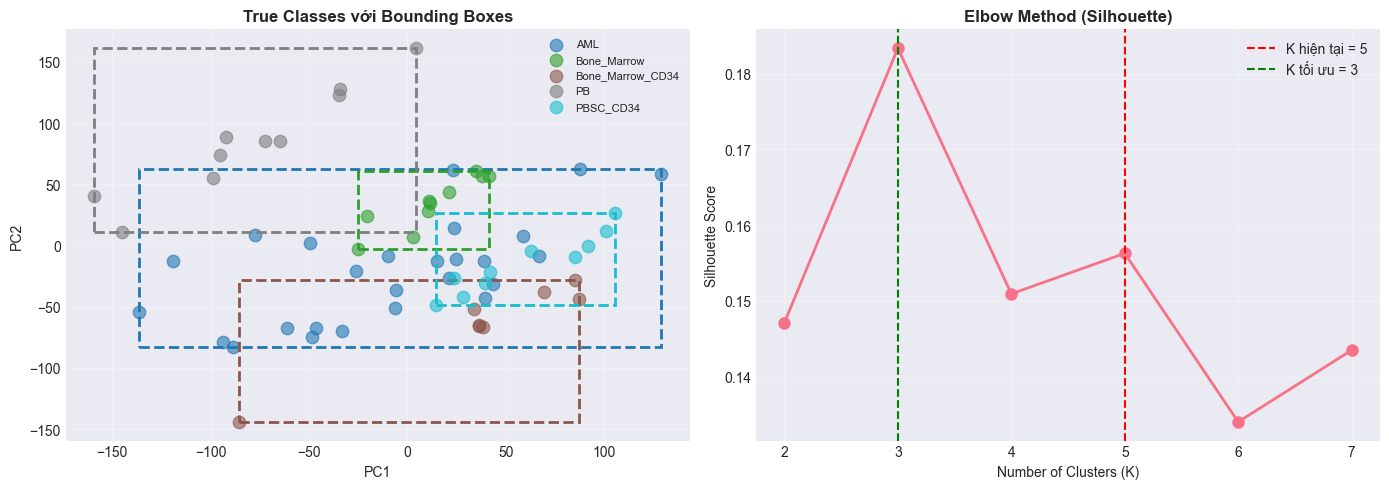


KẾT LUẬN VỀ NGUYÊN NHÂN:

✅ Code ĐÚNG, Ensemble HOẠT ĐỘNG TỐT
❌ Dữ liệu gene expression CÓ BẢN CHẤT OVERLAP CAO

Nguyên nhân metrics thấp:
1. Classes thực sự CHỒNG LẤN trong không gian PCA (xem bounding boxes)
2. PC1+PC2 chỉ giữ ~15-25% variance → mất nhiều thông tin
3. Gene expression data rất phức tạp, không linearly separable
4. Một số classes (Bone_Marrow vs Bone_Marrow_CD34) rất gần nhau về sinh học

Giải pháp có thể:
→ Thử K khác (theo Elbow method ở trên)
→ Feature selection (chọn genes quan trọng thay vì dùng tất cả)
→ Nonlinear dimensionality reduction (t-SNE, UMAP)
→ Deep learning (Autoencoder) để extract features tốt hơn
→ CHẤP NHẬN rằng unsupervised clustering không phải lúc nào cũng match true labels!



In [31]:
print("="*80)
print("PHÂN TÍCH NGUYÊN NHÂN METRICS THẤP")
print("="*80)

# 1. Phân tích overlap giữa các true classes trong không gian PCA
print("\n1️⃣ PHÂN TÍCH CLASS OVERLAP (trong không gian PCA):")
print("\nKhoảng cách trung bình giữa các true classes (PC1-PC2):")
classes = sorted(y_true_str.unique())
for i, c1 in enumerate(classes):
    for c2 in classes[i+1:]:
        mask1 = y_true_str == c1
        mask2 = y_true_str == c2
        center1 = X_pca[mask1][:, :2].mean(axis=0)
        center2 = X_pca[mask2][:, :2].mean(axis=0)
        dist = np.sqrt(np.sum((center1 - center2)**2))
        print(f"  {c1:<20} ↔ {c2:<20}: {dist:>6.2f}")

# 2. Phân tích variance của PCA components
print("\n2️⃣ PHÂN TÍCH PCA VARIANCE:")
print(f"\nTop 10 PCA components:")
for i in range(min(10, len(pca.explained_variance_ratio_))):
    print(f"  PC{i+1}: {pca.explained_variance_ratio_[i]:.4f} ({pca.explained_variance_ratio_[i]*100:.2f}%)")
print(f"\nTổng variance (PC1+PC2): {pca.explained_variance_ratio_[:2].sum()*100:.2f}%")
print(f"→ Visualize 2D chỉ thấy {pca.explained_variance_ratio_[:2].sum()*100:.1f}% thông tin!")
print(f"→ Còn {100-pca.explained_variance_ratio_[:2].sum()*100:.1f}% variance ở các PC khác")

# 3. Intra-class variance (độ phân tán trong mỗi class)
print("\n3️⃣ PHÂN TÍCH INTRA-CLASS VARIANCE:")
print("\nĐộ phân tán (std) của mỗi true class trong PC1-PC2:")
for c in classes:
    mask = y_true_str == c
    points = X_pca[mask][:, :2]
    std = points.std(axis=0).mean()
    print(f"  {c:<25}: std={std:>6.2f} ({np.sum(mask):>2} samples)")

print("\n💡 NẾU độ phân tán trong class CAO → class đó rất 'rải rác' → khó cluster")

# 4. Test với số cluster khác nhau (Elbow method trên Silhouette)
print("\n4️⃣ ELBOW METHOD - Thử các giá trị K khác:")
from sklearn.cluster import KMeans as SK_KMeans
silhouettes = []
K_range = range(2, 8)
for k in K_range:
    kmeans_sk = SK_KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_sk.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    silhouettes.append(sil)
    print(f"  K={k}: Silhouette={sil:.4f}")

best_k = K_range[np.argmax(silhouettes)]
print(f"\n→ K tối ưu theo Silhouette: K={best_k} (Sil={max(silhouettes):.4f})")
print(f"→ K hiện tại: K={K} (Sil={sil_km:.4f})")

# 5. Visualize overlap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot PC1 vs PC2 với bounding boxes
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
for idx, c in enumerate(classes):
    mask = y_true_str == c
    points = X_pca[mask][:, :2]
    axes[0].scatter(points[:, 0], points[:, 1], c=[colors[idx]], s=80, alpha=0.6, label=c)
    
    # Bounding box
    x_min, x_max = points[:, 0].min(), points[:, 0].max()
    y_min, y_max = points[:, 1].min(), points[:, 1].max()
    from matplotlib.patches import Rectangle
    rect = Rectangle((x_min, y_min), x_max-x_min, y_max-y_min, 
                     linewidth=2, edgecolor=colors[idx], facecolor='none', linestyle='--')
    axes[0].add_patch(rect)

axes[0].set_title('True Classes với Bounding Boxes', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(loc='best', fontsize=8); axes[0].grid(alpha=0.3)

# Elbow curve
axes[1].plot(K_range, silhouettes, 'o-', linewidth=2, markersize=8)
axes[1].axvline(K, color='red', linestyle='--', label=f'K hiện tại = {K}')
axes[1].axvline(best_k, color='green', linestyle='--', label=f'K tối ưu = {best_k}')
axes[1].set_xlabel('Number of Clusters (K)'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Elbow Method (Silhouette)', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xticks(K_range)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("KẾT LUẬN VỀ NGUYÊN NHÂN:")
print("="*80)
print("""
✅ Code ĐÚNG, Ensemble HOẠT ĐỘNG TỐT
❌ Dữ liệu gene expression CÓ BẢN CHẤT OVERLAP CAO

Nguyên nhân metrics thấp:
1. Classes thực sự CHỒNG LẤN trong không gian PCA (xem bounding boxes)
2. PC1+PC2 chỉ giữ ~15-25% variance → mất nhiều thông tin
3. Gene expression data rất phức tạp, không linearly separable
4. Một số classes (Bone_Marrow vs Bone_Marrow_CD34) rất gần nhau về sinh học

Giải pháp có thể:
→ Thử K khác (theo Elbow method ở trên)
→ Feature selection (chọn genes quan trọng thay vì dùng tất cả)
→ Nonlinear dimensionality reduction (t-SNE, UMAP)
→ Deep learning (Autoencoder) để extract features tốt hơn
→ CHẤP NHẬN rằng unsupervised clustering không phải lúc nào cũng match true labels!
""")
